## Data Preparation

In [1]:
!pip install tensorflow opencv-python tqdm scikit-learn matplotlib seaborn mtcnn

Defaulting to user installation because normal site-packages is not writeable
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 24.7 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [10]:
!pip install lz4

import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from mtcnn import MTCNN

# ==========================
# Setup Paths and Parameters
# ==========================
REAL_PATH = "./FF++/real"
FAKE_PATH = "./FF++/fake"
WORK_DIR = "./working"
os.makedirs(WORK_DIR, exist_ok=True)

OUTPUT_FRAME_SIZE = (128, 128)
FRAME_COUNT = 10
MAX_VIDEOS = 200
CHECKPOINT_INTERVAL = 50  # save progress every 50 videos

# ==========================
# Verify dataset paths
# ==========================
if not os.path.exists(REAL_PATH) or not os.path.exists(FAKE_PATH):
    raise FileNotFoundError(f"Dataset paths not found. REAL_PATH={REAL_PATH}, FAKE_PATH={FAKE_PATH}")

detector = MTCNN()

# ==========================
# Helper functions
# ==========================
def extract_face(frame):
    results = detector.detect_faces(frame)
    if results:
        x, y, w, h = results[0]['box']
        x, y = max(0, x), max(0, y)
        face = frame[y:y+h, x:x+w]
        return cv2.resize(face, OUTPUT_FRAME_SIZE)
    return cv2.resize(frame, OUTPUT_FRAME_SIZE)

def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Warning: Could not open {video_path}")
        return np.array([])
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = extract_face(frame)
        frames.append(frame)
    cap.release()
    return np.array(frames) if len(frames) > 0 else np.zeros((frame_count, output_size[0], output_size[1], 3), dtype=np.uint8)

# ==========================
# Load checkpoint if exists
# ==========================
checkpoint_file = os.path.join(WORK_DIR, "checkpoint.npy")
if os.path.exists(checkpoint_file):
    print("Loading checkpoint...")
    checkpoint = np.load(checkpoint_file, allow_pickle=True).item()
    data = checkpoint["data"]
    labels = checkpoint["labels"]
    processed_real = checkpoint["processed_real"]
    processed_fake = checkpoint["processed_fake"]
else:
    data, labels = [], []
    processed_real, processed_fake = 0, 0

# ==========================
# Process Real Videos
# ==========================
print("Processing real videos...")
real_videos = os.listdir(REAL_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(real_videos[processed_real:]), start=processed_real):
    video_path = os.path.join(REAL_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(0)
    processed_real += 1

    # Save checkpoint every 50 videos
    if processed_real % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_real} real videos")

# ==========================
# Process Fake Videos
# ==========================
print("Processing fake videos...")
fake_videos = os.listdir(FAKE_PATH)[:MAX_VIDEOS]
for i, video_file in enumerate(tqdm(fake_videos[processed_fake:]), start=processed_fake):
    video_path = os.path.join(FAKE_PATH, video_file)
    frames = extract_frames(video_path, OUTPUT_FRAME_SIZE, FRAME_COUNT)
    if len(frames) == FRAME_COUNT:
        data.append(frames)
        labels.append(1)
    processed_fake += 1

    # Save checkpoint every 50 videos
    if processed_fake % CHECKPOINT_INTERVAL == 0:
        np.save(checkpoint_file, {
            "data": data,
            "labels": labels,
            "processed_real": processed_real,
            "processed_fake": processed_fake
        })
        print(f"Checkpoint saved at {processed_fake} fake videos")

# ==========================
# Final Save
# ==========================
if len(data) == 0:
    raise ValueError("No valid frames extracted.")

data = np.array(data)
labels = np.array(labels)

# Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Normalize
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=2)
y_val = to_categorical(y_val, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)

# Save final outputs
np.save(os.path.join(WORK_DIR, "X_train.npy"), X_train)
np.save(os.path.join(WORK_DIR, "y_train.npy"), y_train)
np.save(os.path.join(WORK_DIR, "X_val.npy"), X_val)
np.save(os.path.join(WORK_DIR, "y_val.npy"), y_val)
np.save(os.path.join(WORK_DIR, "X_test.npy"), X_test)
np.save(os.path.join(WORK_DIR, "y_test.npy"), y_test)

# Save final checkpoint (for traceability)
np.save(os.path.join(WORK_DIR, "final_checkpoint.npy"), {
    "processed_real": processed_real,
    "processed_fake": processed_fake,
    "total_data": len(data)
})

print(f"✅ Data saved successfully in {WORK_DIR}")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Files:", os.listdir(WORK_DIR))


Defaulting to user installation because normal site-packages is not writeable
Processing real videos...


  0%|                                                                                                                                                                                   | 0/200 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

  0%|▊                                                                                                                                                                          | 1/200 [00:05<18:23,  5.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
11/11 ━━━━━━━━━━━━━━━━

...

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 199/200 [21:47<00:06,  6.67s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
7/7 ━━━━━━━━━━━━━━━━━

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [21:54<00:00,  6.57s/it]

Checkpoint saved at 200 fake videos


✅ Data saved successfully in ./working
Train: (280, 10, 128, 128, 3) Val: (60, 10, 128, 128, 3) Test: (60, 10, 128, 128, 3)
Files: ['y_train.npy', 'checkpoint.npy', 'y_test.npy', 'X_test.npy', 'y_val.npy', 'X_train.npy', 'X_val.npy', 'final_checkpoint.npy']


## Data Augmentation

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=40,
    zoom_range=0.4,
    brightness_range=[0.5, 1.5],
    shear_range=0.4,
    width_shift_range=0.3,
    height_shift_range=0.3,
    channel_shift_range=10.0,
    fill_mode='nearest'
)

def augment_frames(frames):
    augmented_frames = []
    for frame in frames:
        frame = datagen.random_transform(frame)
        augmented_frames.append(frame)
    return np.array(augmented_frames)

augmented_data = []
augmented_labels = []

for i in tqdm(range(len(X_train))):
    augmented_frames = augment_frames(X_train[i])
    augmented_data.append(augmented_frames)
    augmented_labels.append(y_train[i])

X_train_augmented = np.concatenate((X_train, np.array(augmented_data)))
y_train_augmented = np.concatenate((y_train, np.array(augmented_labels)))

print(f"Augmented Train Data: {X_train_augmented.shape}")
np.save(os.path.join(WORK_DIR, "X_train_augmented.npy"), X_train_augmented)
np.save(os.path.join(WORK_DIR, "Y_train_augmented.npy"), y_train_augmented)
print(f"files: ", os.listdir(WORK_DIR))

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 280/280 [00:03<00:00, 70.68it/s]


Augmented Train Data: (560, 10, 128, 128, 3)
files:  ['Y_train_augmented.npy', 'X_train_augmented.npy', 'y_train.npy', 'checkpoint.npy', 'y_test.npy', 'X_test.npy', 'y_val.npy', 'X_train.npy', 'X_val.npy', 'final_checkpoint.npy']


## Model Architecture

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, TimeDistributed, Bidirectional, GRU, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2

def build_best_model(input_shape=(FRAME_COUNT, 128, 128, 3)):
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = True
    for layer in base_model.layers[:-30]:  # Unfreeze last 30 layers for fine-tuning
        layer.trainable = False

    model = Sequential([
        TimeDistributed(base_model),
        TimeDistributed(GlobalAveragePooling2D()),
        BatchNormalization(),
        Bidirectional(GRU(128, return_sequences=False, kernel_regularizer=l2(0.005))),
        Dropout(0.5),
        Dense(64, activation='relu', kernel_regularizer=l2(0.005)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(2, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_best_model()
model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 8,940,352 (34.10 MB)

 Non-trainable params: 11,921,128 (45.48 MB)

## Model Training

In [16]:
import os
import json
import pandas as pd
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from sklearn.utils import class_weight

# ==========================
# Setup directories
# ==========================
WORK_DIR = "./working"
os.makedirs(WORK_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
FINAL_MODEL_PATH = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
HISTORY_JSON_PATH = os.path.join(WORK_DIR, "training_history.json")
HISTORY_CSV_PATH = os.path.join(WORK_DIR, "training_history.csv")

# ==========================
# Compute class weights
# ==========================
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(np.argmax(y_train, axis=1)),
    y=np.argmax(y_train, axis=1)
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

# ==========================
# Callbacks
# ==========================
checkpoint = ModelCheckpoint(
    BEST_MODEL_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# ==========================
# Train the model
# ==========================
history = model.fit(
    X_train_augmented, y_train_augmented,
    validation_data=(X_val, y_val),
    epochs=20,  # Increase to ~100 for full training
    batch_size=8,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, lr_scheduler, early_stopping],
    verbose=1
)

# ==========================
# Save the final model
# ==========================
model.save(FINAL_MODEL_PATH)
print(f"✅ Final model saved at: {FINAL_MODEL_PATH}")

# ==========================
# Save training history
# ==========================
history_dict = history.history

# Save as JSON
with open(HISTORY_JSON_PATH, "w") as f:
    json.dump(history_dict, f, indent=4)
print(f"📘 Training history saved as JSON at: {HISTORY_JSON_PATH}")

# Save as CSV
pd.DataFrame(history_dict).to_csv(HISTORY_CSV_PATH, index=False)
print(f"📗 Training history saved as CSV at: {HISTORY_CSV_PATH}")

# ==========================
# Verify saved files
# ==========================
print("\n📁 Files saved in working directory:")
for f in os.listdir(WORK_DIR):
    print(" -", f)


Class weights: {0: np.float64(1.0144927536231885), 1: np.float64(0.9859154929577465)}
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 971ms/step - accuracy: 0.5548 - loss: 7.9473
Epoch 1: val_accuracy improved from -inf to 0.60000, saving model to ./working/deepfake_detection_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.5543 - loss: 7.9464 - val_accuracy: 0.6000 - val_loss: 7.2556 - learning_rate: 1.0000e-04
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.5403 - loss: 7.6893
Epoch 2: val_accuracy improved from 0.60000 to 0.75000, saving model to ./working/deepfake_detection_best.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.5404 - loss: 7.6866 - val_accuracy: 0.7500 - val_loss: 6.7275 - learning_rate: 1.0000e-04
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5984 - loss: 7.0301
Epoch 3: val_accuracy did not improve from 0.75000
70/70 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.5986 - loss: 7.0282 - val_accuracy: 0.7500 - val

## Model Testing

✅ Model loaded successfully from ./working/deepfake_detection_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 6s/step

🎯 Test Accuracy: 90.00%

📊 Classification Report:
              precision    recall  f1-score   support

        REAL       0.89      0.94      0.91        33
        FAKE       0.92      0.85      0.88        27

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

💾 Training history saved successfully.


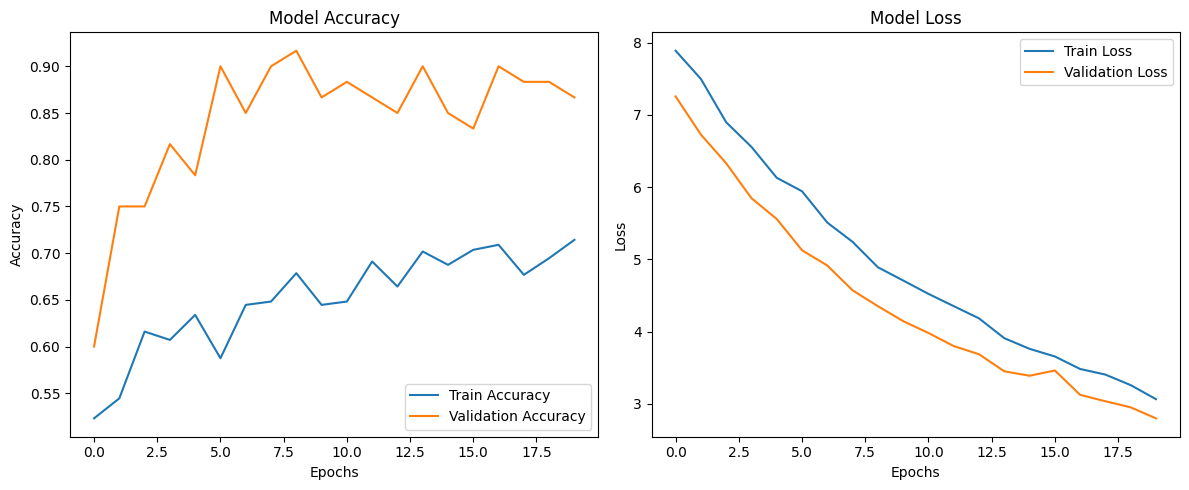

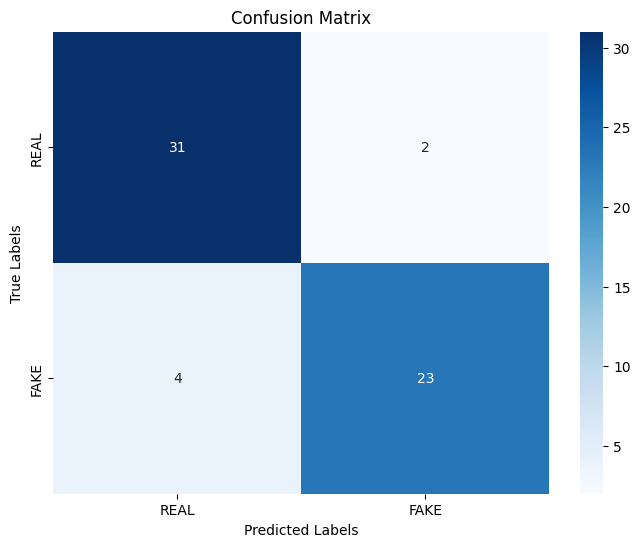


Detailed Classification Report:
              precision    recall  f1-score   support

        REAL       0.89      0.94      0.91        33
        FAKE       0.92      0.85      0.88        27

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In [19]:
# --- Evaluation & Visualization ---

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# --- Load trained model ---
model_path = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
final_model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")

try:
    model = load_model(model_path)
    print(f"✅ Model loaded successfully from {model_path}")
except Exception as e:
    print(f"⚠️ Could not load {model_path}. Trying final model instead.")
    model = load_model(final_model_path)
    print(f"✅ Model loaded successfully from {final_model_path}")

# --- Predict & Evaluate ---
y_pred = model.predict(X_test, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
print(f"\n🎯 Test Accuracy: {accuracy * 100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=['REAL', 'FAKE']))

# --- Load training history if running in new session ---
if 'history' not in locals():
    try:
        history = joblib.load("training_history.pkl")
        print("✅ Training history loaded successfully.")
    except:
        print("⚠️ No history found. Skipping training plot.")

# --- Plot training history ---
def plot_training_history(history):
    if history is None:
        print("⚠️ No history available to plot.")
        return

    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# --- Confusion Matrix Plot ---
def plot_confusion_matrix(model, X_test, y_test):
    y_pred = model.predict(X_test, verbose=0)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred_classes)
    labels = ['REAL', 'FAKE']

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=labels))

# --- Save history for future sessions ---
try:
    joblib.dump(history, "training_history.pkl")
    print("💾 Training history saved successfully.")
except:
    print("⚠️ Could not save training history (ignored).")

# --- Run plots ---
plot_training_history(history)
plot_confusion_matrix(model, X_test, y_test)


## Real Time Detection


In [22]:
# Real-Time Detection
import cv2
import numpy as np
import os
from tensorflow.keras.models import load_model

# Function to extract frames from a video
def extract_frames(video_path, output_size=(128, 128), frame_count=10):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return np.array([])  # Return empty array if video fails to open
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // frame_count, 1)  # Uniform sampling
    
    for i in range(frame_count):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, output_size)  # Resize frame
        frames.append(frame)
    cap.release()
    
    # Convert to NumPy array and ensure 4D shape
    if len(frames) == 0:
        print(f"Warning: No frames extracted from {video_path}")
        return np.zeros((0, output_size[0], output_size[1], 3), dtype=np.uint8)
    return np.array(frames, dtype=np.uint8)

# Function to predict video
def predict_video(video_path, model, output_size=(128, 128), frame_count=10):
    frames = extract_frames(video_path, output_size, frame_count)
    if len(frames) == 0:
        print(f"Error: No frames to predict for {video_path}")
        return
    
    # Ensure frames is 4D
    if len(frames.shape) == 3:  # (height, width, channels)
        frames = np.expand_dims(frames, axis=0)  # Make it (1, height, width, channels)
    elif len(frames.shape) == 4 and frames.shape[0] < frame_count:
        pad_length = frame_count - frames.shape[0]
        pad_width = [(0, pad_length)] + [(0, 0) for _ in range(len(frames.shape) - 1)]
        frames = np.pad(frames, pad_width, mode='constant', constant_values=0)
    elif len(frames.shape) != 4:
        print(f"Error: Unexpected frame shape {frames.shape} for {video_path}")
        return

    frames = frames / 255.0  # Normalize
    frames = np.expand_dims(frames, axis=0)  # Add batch dimension
    prediction = model.predict(frames)
    label = "FAKE" if np.argmax(prediction) == 1 else "REAL"
    confidence = float(prediction[0][np.argmax(prediction)])
    print(f"Prediction: {label} (Confidence: {confidence:.2f})")

# Load the model with file existence check
model_path = os.path.join(WORK_DIR, "deepfake_detection_best.keras")
final_model_path = os.path.join(WORK_DIR, "deepfake_detection_final.keras")
if os.path.exists(model_path):
    loaded_model = load_model(model_path)
    print(f"Model loaded successfully from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}. Please run the training section first.")
    raise FileNotFoundError(f"Model file not found at {model_path}")

# Use the same dataset paths as data loading
REAL_PATH = "./FF++/real"
FAKE_PATH = "./FF++/fake"

# Get the first available video files (verify they exist)
real_videos = os.listdir(REAL_PATH)
fake_videos = os.listdir(FAKE_PATH)
if not real_videos or not fake_videos:
    print("Error: No video files found in REAL_PATH or FAKE_PATH. Check dataset input.")
else:
    real_sample_path = os.path.join(REAL_PATH, real_videos[0])  # First real video
    fake_sample_path = os.path.join(FAKE_PATH, fake_videos[0])  # First fake video

    # Test predictions
    print("Real Video Prediction:")
    predict_video(real_sample_path, loaded_model)

    print("Fake Video Prediction:")
    predict_video(fake_sample_path, loaded_model)

# List contents of /kaggle/working/ to verify model or other files
!ls -lh /kaggle/working/

Model loaded successfully from ./working/deepfake_detection_best.keras
Real Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Prediction: REAL (Confidence: 1.00)
Fake Video Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Prediction: REAL (Confidence: 0.98)
ls: /kaggle/working/: No such file or directory


In [ ]:
!ls -lh /kaggle/working/

In [ ]:
!ls -lh /kaggle/working/deepfake_detection_model.keras